<a href="https://colab.research.google.com/github/marcuslee6/Signal-and-Systems/blob/main/poles%20and%20zeroes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

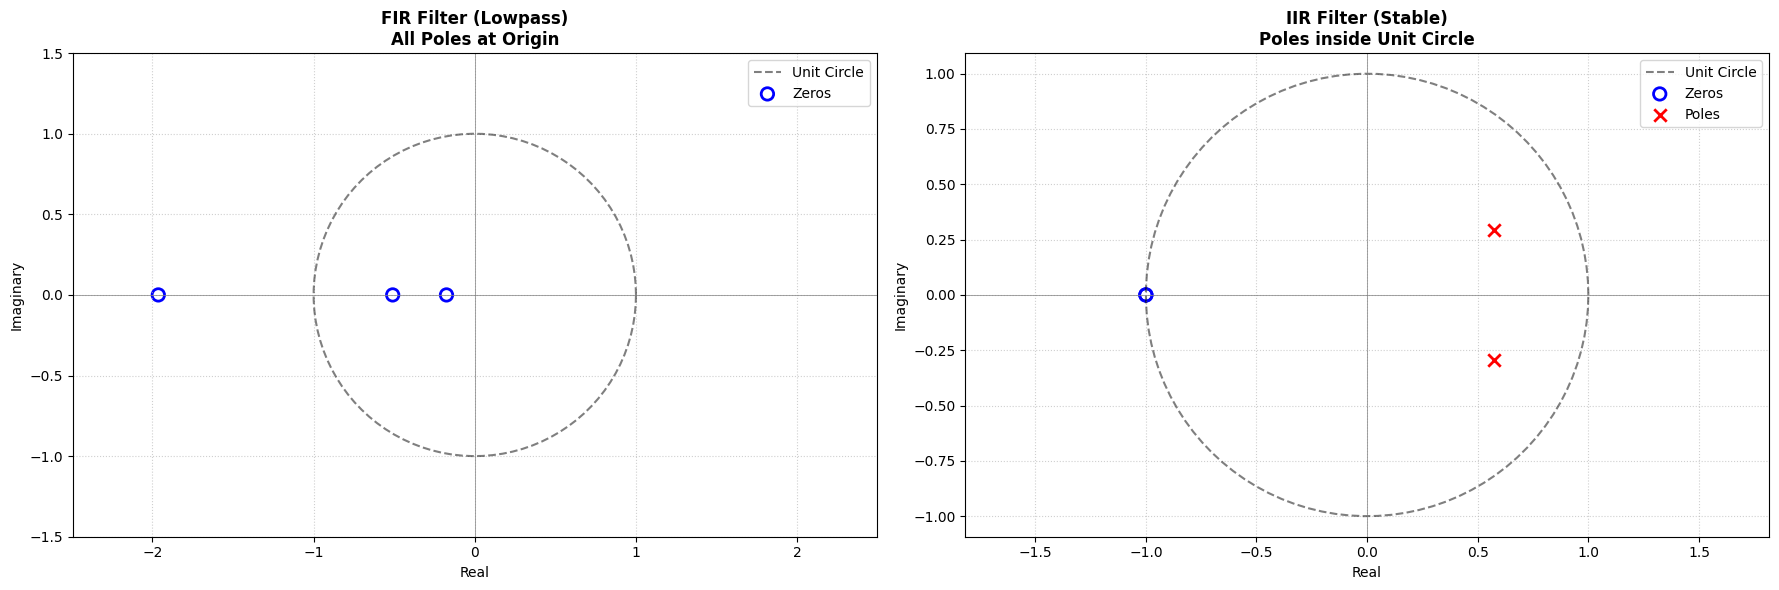

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_pole_zero(b, a, title, ax):
    """Draw zeroes and poles"""
    # zeroes and poles
    zeros = np.roots(b)
    poles = np.roots(a)

    # Draw Unit Circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit Circle', alpha=0.5)

    # Draw real axis and imaginary axis
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

    # Draw Zeros - Blue dots
    if len(zeros) > 0:
        ax.scatter(np.real(zeros), np.imag(zeros), s=80, facecolors='none', edgecolors='blue', marker='o', lw=2, label='Zeros')

    # Draw Poles - Red cross
    if len(poles) > 0:
        ax.scatter(np.real(poles), np.imag(poles), s=80, color='red', marker='x', lw=2, label='Poles')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axis('equal')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.legend(loc='upper right')

# --- FIX: Main script body must be un-indented ---

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# -------------------------------------------------------------------------
# 1. FIR (Finite Impulse Response) - Order=4
# -------------------------------------------------------------------------
num_taps = 5 # order=4
cutoff_fir = 0.2
b_fir = signal.firwin(num_taps, cutoff_fir)
a_fir = [1.0]

plot_pole_zero(b_fir, a_fir, "FIR Filter (Lowpass)\nAll Poles at Origin", axs[0])

# -------------------------------------------------------------------------
# 2. Stable IIR (Infinite Impulse Response) - 2nd order butterworth
# -------------------------------------------------------------------------
b_iir, a_iir = signal.butter(N=2, Wn=0.2, btype='low')

plot_pole_zero(b_iir, a_iir, "IIR Filter (Stable)\nPoles inside Unit Circle", axs[1])

# Show results
plt.tight_layout()
plt.show()